# Notebook 05: Full-Scale RF Parameter Analysis

Scaled version of Notebook 04, processing **all 17 containers (~3,669 neurons)**.

## Analysis pipeline
1. **Batch extraction** — σ, θ, κ from sparse noise (Session C), crash-safe with per-container saves
2. **Population statistics** — parameter distributions across the full L2/3 excitatory dataset
3. **Cascade smoothing test** — CV of σ across the full dataset
4. **Cortical position analysis** — ROI centroids → spatial autocorrelation of κ
5. **σ-κ coupling vs positional coupling** — the key comparison for Lindeberg (2025c)
6. **Cross-container comparison** — by Cre line and imaging depth

---

**Reference:** Lindeberg (2025c) 'Do the receptive fields in the primary visual cortex span a variability over the degree of elongation?' *J. Comput. Neurosci.* 53(3):397-417


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, circstd
from scipy.spatial.distance import pdist, squareform
from allensdk.core.brain_observatory_cache import BrainObservatoryCache
import sys, os, warnings, time
from pathlib import Path
from matplotlib.patches import Ellipse


sys.path.insert(0, os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study/src'))
from rf_analysis.sparse_noise import (
    reconstruct_rf, fit_gaussian_derivative, extract_spatial_parameters,
    batch_extract_spatial_parameters, gaussian_2d,
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
warnings.filterwarnings('ignore')

print('✓ Imports successful')


In [2]:
base_dir    = Path(os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study'))
cache_dir   = base_dir / 'data' / 'cache'
lists_dir   = base_dir / 'data' / 'experiment_lists'
outputs_dir = base_dir / 'outputs' / 'rf_params'
outputs_dir.mkdir(parents=True, exist_ok=True)

manifest_path = str(cache_dir / 'manifest.json')
boc = BrainObservatoryCache(manifest_file=manifest_path)

# Load experiment metadata
batch_df        = pd.read_csv(lists_dir / 'all_l23_excitatory_experiments.csv')
container_meta  = pd.read_csv(lists_dir / 'container_neuron_counts.csv')
verify_df       = pd.read_csv(lists_dir / 'downloaded_all_l23_excitatory_experiments.csv')
downloaded      = set(verify_df[verify_df['exists']]['experiment_id'].tolist())

# Session C experiments for downloaded, complete containers
complete_ids = set(container_meta['container_id'].tolist())
session_c = batch_df[
    batch_df['session_type'].str.contains('C') &
    batch_df['id'].isin(downloaded) &
    batch_df['experiment_container_id'].isin(complete_ids)
].copy()

print(f'✓ Complete containers: {len(complete_ids)}')
print(f'✓ Session C experiments to process: {len(session_c)}')
print(f'✓ Expected neurons: ~{container_meta["n_neurons"].sum():,}')
print(f'✓ Output directory: {outputs_dir}')


✓ Complete containers: 17
✓ Session C experiments to process: 17
✓ Expected neurons: ~3,669
✓ Output directory: /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params


---

## Part 1: Batch RF Parameter Extraction

Processes all Session C experiments. **Crash-safe**: saves a CSV per container immediately after fitting.
Re-running skips any container that already has a saved file.

Uses `batch_extract_spatial_parameters()`:
- Loads all ΔF/F traces in **one NWB read** per container
- Builds the stimulus design matrix **once** per container
- Solves multi-output ridge with **GCV** (analytical LOO, no k-fold) — SVD shared across all neurons
- Expected: **2–5 min per container**, ~1 hour total (vs ~8 h with per-neuron fitting)


In [ ]:
QUALITY_THRESHOLD = 0.3
PIXEL_SIZE_UM     = 0.78   # μm per pixel, standard Allen 2P

batch_log = []
t_start   = time.time()

for row_i, exp_row in session_c.iterrows():
    container_id = exp_row['experiment_container_id']
    exp_id       = exp_row['id']
    cre_line     = exp_row['cre_line']
    depth        = exp_row['imaging_depth']

    out_file = outputs_dir / f'rf_params_container_{container_id}.csv'

    # --- Skip if already done ---
    if out_file.exists():
        df_existing = pd.read_csv(out_file)
        print(f'  [SKIP] Container {container_id}: {len(df_existing)} neurons (already saved)')
        batch_log.append({'container_id': container_id, 'exp_id': exp_id,
                          'cre_line': cre_line, 'depth': depth,
                          'n_success': len(df_existing), 'n_total': len(df_existing),
                          'status': 'cached'})
        continue

    print(f'\n[{row_i+1}/{len(session_c)}] Container {container_id}  |  exp {exp_id}'
          f'  |  {cre_line}  |  {depth} μm')

    try:
        dataset  = boc.get_ophys_experiment_data(exp_id)
        cell_ids = dataset.get_cell_specimen_ids()
        n_total  = len(cell_ids)
        print(f'  Neurons: {n_total}')

        t0 = time.time()

        # --- Batch RF extraction (single NWB read, design matrix built once) ---
        results = batch_extract_spatial_parameters(
            dataset, cell_ids,
            quality_threshold=QUALITY_THRESHOLD,
        )

        elapsed = time.time() - t0
        print(f'  Ridge batch done in {elapsed:.0f}s  ({elapsed/n_total:.1f}s/neuron)')

        # --- Cortical xy from ROI centroids ---
        if results:
            fitted_ids = [r['cell_id'] for r in results]
            roi_masks  = dataset.get_roi_mask(cell_specimen_ids=fitted_ids)
            pos_map    = {}
            for cid, roi in zip(fitted_ids, roi_masks):
                coords = np.argwhere(roi.mask)
                if len(coords):
                    cy = roi.y + coords[:, 0].mean()
                    cx = roi.x + coords[:, 1].mean()
                else:
                    cx = roi.x + roi.width  / 2
                    cy = roi.y + roi.height / 2
                pos_map[cid] = (cx * PIXEL_SIZE_UM, cy * PIXEL_SIZE_UM)

            for r in results:
                r['cortex_x_um'], r['cortex_y_um'] = pos_map.get(r['cell_id'], (np.nan, np.nan))

        # --- Save ---
        df_c = pd.DataFrame(results)
        df_c['container_id'] = container_id
        df_c['exp_id']       = exp_id
        df_c['cre_line']     = cre_line
        df_c['depth_um']     = depth
        df_c.to_csv(out_file, index=False)

        pct = 100 * len(results) / n_total if n_total else 0
        print(f'  ✓ Saved: {len(results)}/{n_total} neurons ({pct:.1f}%)  →  {out_file.name}')

        batch_log.append({'container_id': container_id, 'exp_id': exp_id,
                          'cre_line': cre_line, 'depth': depth,
                          'n_success': len(results), 'n_total': n_total, 'status': 'done'})

    except Exception as e:
        print(f'  ✗ ERROR: {e}')
        batch_log.append({'container_id': container_id, 'exp_id': exp_id,
                          'cre_line': cre_line, 'depth': depth,
                          'n_success': 0, 'n_total': 0, 'status': f'error: {e}'})

total_time = time.time() - t_start
print(f'\n' + '='*60)
print(f'BATCH COMPLETE — {total_time/60:.1f} min total')
log_df = pd.DataFrame(batch_log)
print(log_df[['container_id', 'cre_line', 'depth', 'n_success', 'n_total', 'status']].to_string(index=False))


In [4]:
# --- Load all saved per-container CSVs into one DataFrame ---
csv_files = sorted(outputs_dir.glob('rf_params_container_*.csv'))
print(f'Found {len(csv_files)} saved container files')

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    # Back-fill container metadata if old files missing these columns
    if 'container_id' not in df.columns:
        cid = int(f.stem.split('_')[-1])
        df['container_id'] = cid
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

# Ensure numeric types
for col in ['sigma', 'theta', 'kappa', 'r_squared', 'cortex_x_um', 'cortex_y_um']:
    if col in all_df.columns:
        all_df[col] = pd.to_numeric(all_df[col], errors='coerce')

print(f'\n✓ Combined dataset: {len(all_df):,} neurons across {all_df["container_id"].nunique()} containers')
print(f'  Cre lines: {all_df["cre_line"].unique()}')
print(f'  Depths: {sorted(all_df["depth_um"].unique())} μm')
print(f'\nColumn overview:')
print(all_df[['sigma','theta','kappa','r_squared','cortex_x_um','cortex_y_um']].describe().round(3))


Found 17 saved container files

✓ Combined dataset: 974 neurons across 17 containers
  Cre lines: ['Cux2-CreERT2' 'Slc17a7-IRES2-Cre']
  Depths: [175, 205] μm

Column overview:
         sigma    theta    kappa  r_squared  cortex_x_um  cortex_y_um
count  974.000  974.000  974.000    974.000      974.000      974.000
mean     7.153  101.718    1.748      0.504      197.117      206.248
std      2.527   74.231    0.718      0.157      102.928      103.993
min      3.564    0.000    1.010      0.300       12.243       10.177
25%      5.449   14.597    1.315      0.371      114.068      120.673
50%      6.395  136.947    1.537      0.467      196.166      211.349
75%      8.103  173.905    1.924      0.616      284.547      297.545
max     19.458  180.000    6.527      0.931      391.101      386.379


---

## Part 2: Population Parameter Distributions

Testing Lindeberg's predictions on the full L2/3 excitatory dataset.


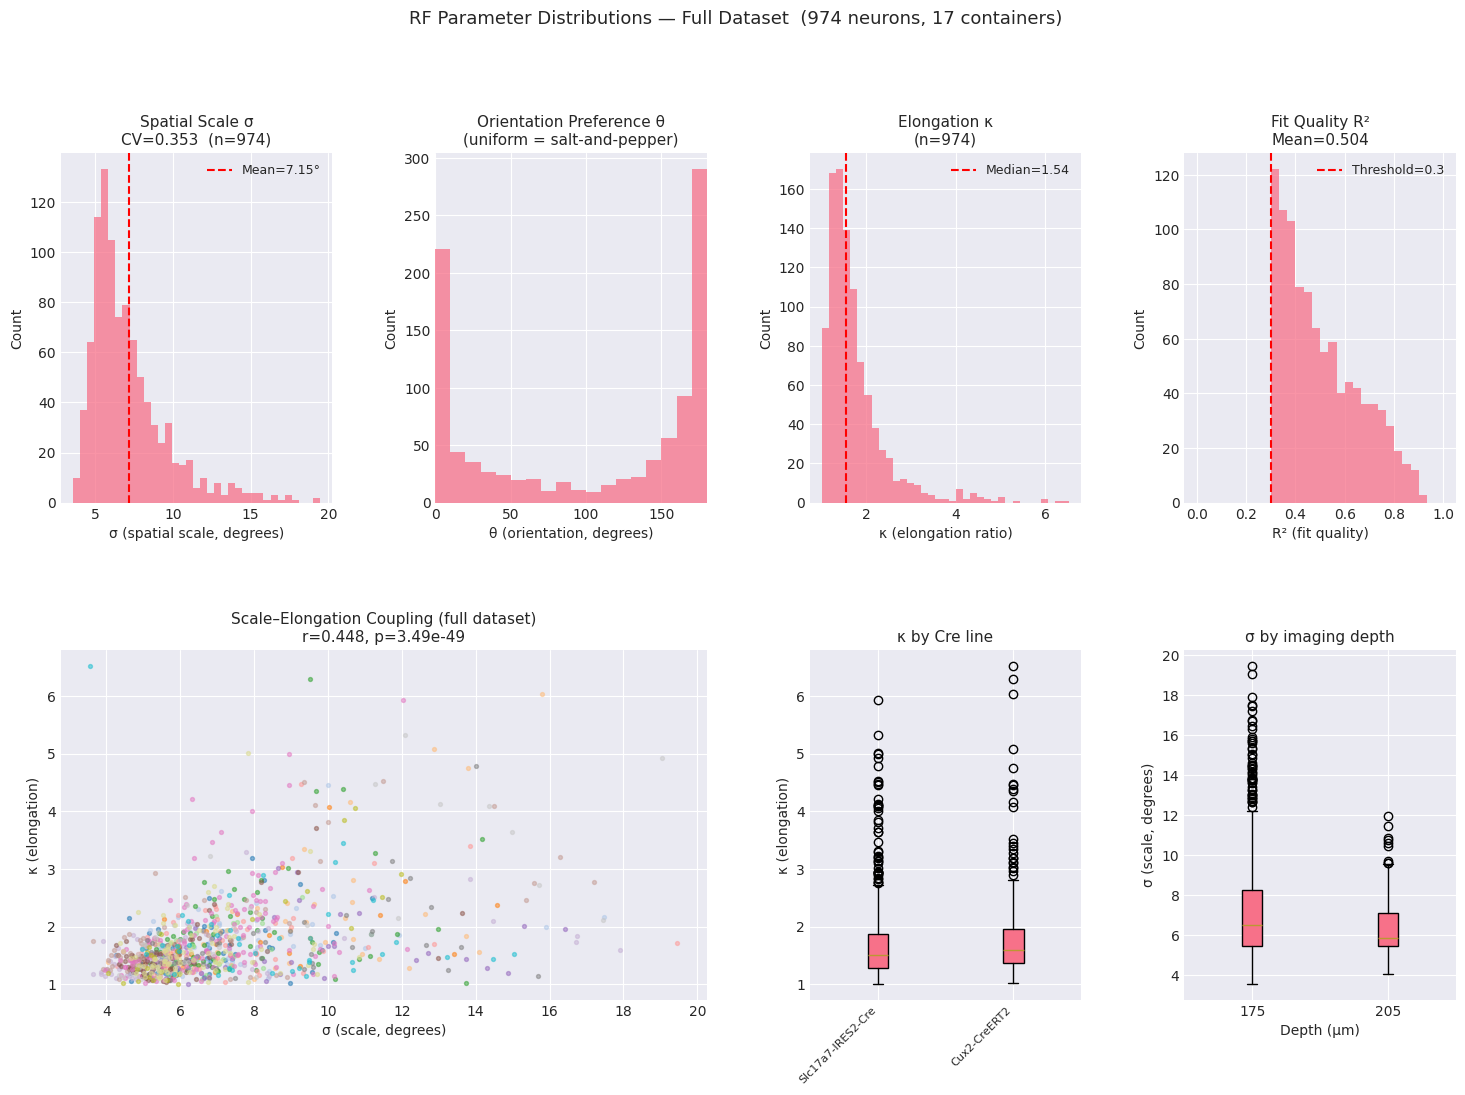

✓ Saved: fig_population_distributions.png


In [7]:
fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.42, wspace=0.38)

sigma_cv = all_df['sigma'].std() / all_df['sigma'].mean()

# --- σ ---
ax0 = fig.add_subplot(gs[0, 0])
ax0.hist(all_df['sigma'].dropna(), bins=35, edgecolor='none', alpha=0.75)
ax0.axvline(all_df['sigma'].mean(), color='red', linestyle='--',
            label=f"Mean={all_df['sigma'].mean():.2f}°")
ax0.set_xlabel('σ (spatial scale, degrees)', fontsize=10)
ax0.set_ylabel('Count')
ax0.set_title(f'Spatial Scale σ\nCV={sigma_cv:.3f}  (n={all_df["sigma"].notna().sum():,})', fontsize=11)
ax0.legend(fontsize=9)

# --- θ ---
ax1 = fig.add_subplot(gs[0, 1])
ax1.hist(all_df['theta'].dropna(), bins=18, range=(0, 180), edgecolor='none', alpha=0.75)
ax1.set_xlabel('θ (orientation, degrees)', fontsize=10)
ax1.set_ylabel('Count')
ax1.set_title('Orientation Preference θ\n(uniform = salt-and-pepper)', fontsize=11)
ax1.set_xlim(0, 180)

# --- κ ---
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(all_df['kappa'].dropna(), bins=35, edgecolor='none', alpha=0.75)
ax2.axvline(all_df['kappa'].median(), color='red', linestyle='--',
            label=f"Median={all_df['kappa'].median():.2f}")
ax2.set_xlabel('κ (elongation ratio)', fontsize=10)
ax2.set_ylabel('Count')
ax2.set_title(f'Elongation κ\n(n={all_df["kappa"].notna().sum():,})', fontsize=11)
ax2.legend(fontsize=9)

# --- R² ---
ax3 = fig.add_subplot(gs[0, 3])
ax3.hist(all_df['r_squared'].dropna(), bins=30, range=(0, 1), edgecolor='none', alpha=0.75)
ax3.axvline(0.3, color='red', linestyle='--', label='Threshold=0.3')
ax3.set_xlabel('R² (fit quality)', fontsize=10)
ax3.set_ylabel('Count')
ax3.set_title(f'Fit Quality R²\nMean={all_df["r_squared"].mean():.3f}', fontsize=11)
ax3.legend(fontsize=9)

# --- σ–κ scatter (full dataset, colour by container) ---
ax4 = fig.add_subplot(gs[1, 0:2])
sk_clean = all_df[['sigma', 'kappa', 'container_id']].dropna()
r_sk, p_sk = pearsonr(sk_clean['sigma'], sk_clean['kappa'])
containers_sorted = sorted(all_df['container_id'].unique())
cmap_c = plt.cm.tab20
for i, cid in enumerate(containers_sorted):
    sub = all_df[all_df['container_id'] == cid]
    ax4.scatter(sub['sigma'], sub['kappa'], s=8, alpha=0.5,
                color=cmap_c(i / len(containers_sorted)), label=str(cid))
ax4.set_xlabel('σ (scale, degrees)', fontsize=10)
ax4.set_ylabel('κ (elongation)', fontsize=10)
ax4.set_title(f'Scale–Elongation Coupling (full dataset)\nr={r_sk:.3f}, p={p_sk:.2e}', fontsize=11)

# --- κ by Cre line ---
ax5 = fig.add_subplot(gs[1, 2])
cre_order = all_df.groupby('cre_line')['kappa'].median().sort_values().index.tolist()
kappa_by_cre = [all_df.loc[all_df['cre_line'] == c, 'kappa'].dropna() for c in cre_order]
ax5.boxplot(kappa_by_cre, labels=cre_order, patch_artist=True)
ax5.set_xticklabels(cre_order, rotation=45, ha='right', fontsize=8)
ax5.set_title('κ by Cre line', fontsize=11)
ax5.set_xlabel('')
ax5.set_ylabel('κ (elongation)', fontsize=10)

# --- σ by depth ---
ax6 = fig.add_subplot(gs[1, 3])
depth_order = sorted(all_df['depth_um'].dropna().unique())
depth_data  = [all_df[all_df['depth_um'] == d]['sigma'].dropna() for d in depth_order]
ax6.boxplot(depth_data, labels=[f'{int(d)}' for d in depth_order], patch_artist=True)
ax6.set_title('σ by imaging depth', fontsize=11)
ax6.set_xlabel('Depth (μm)', fontsize=10)
ax6.set_ylabel('σ (scale, degrees)', fontsize=10)

fig.suptitle(f'RF Parameter Distributions — Full Dataset  ({len(all_df):,} neurons, {all_df["container_id"].nunique()} containers)',
             fontsize=13, y=1.01)
plt.savefig(outputs_dir / 'fig_population_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved: fig_population_distributions.png')


In [8]:
print('=' * 65)
print('POPULATION STATISTICAL SUMMARY')
print('=' * 65)

sigma_mean = all_df['sigma'].mean()
sigma_std  = all_df['sigma'].std()
sigma_cv   = sigma_std / sigma_mean

print(f'\nNeurons: {len(all_df):,} across {all_df["container_id"].nunique()} containers')

print(f'\nSpatial Scale σ:')
print(f'  Mean ± SD : {sigma_mean:.2f} ± {sigma_std:.2f}°')
print(f'  Range     : [{all_df["sigma"].min():.2f}, {all_df["sigma"].max():.2f}]°')
print(f'  CV        : {sigma_cv:.3f}')
if sigma_cv < 0.3:
    print(f'  ✓ NARROW (CV < 0.3) → supports cascade smoothing hypothesis')
else:
    print(f'  ✗ BROAD (CV ≥ 0.3) → full scale representation')

print(f'\nElongation κ:')
print(f'  Median    : {all_df["kappa"].median():.2f}')
print(f'  Mean ± SD : {all_df["kappa"].mean():.2f} ± {all_df["kappa"].std():.2f}')
print(f'  75th pct  : {all_df["kappa"].quantile(0.75):.2f}')
print(f'  95th pct  : {all_df["kappa"].quantile(0.95):.2f}')
print(f'  κ > 3     : {(all_df["kappa"] > 3).sum()} / {all_df["kappa"].notna().sum()} '
      f'({100*(all_df["kappa"]>3).mean():.1f}%)')

print(f'\nOrientation θ:')
theta_rad = np.deg2rad(all_df['theta'].dropna())
circ_std  = np.rad2deg(circstd(theta_rad * 2) / 2)  # double-angle trick for [0,180)
print(f'  Circular SD: {circ_std:.1f}°  (uniform distribution would give ~52°)')

print(f'\nFit Quality R²:')
print(f'  Mean ± SD : {all_df["r_squared"].mean():.3f} ± {all_df["r_squared"].std():.3f}')

print(f'\nParameter Coupling (Pearson r, full dataset):')
corr = all_df[['sigma','theta','kappa']].corr()
print(f'  r(σ, θ) = {corr.loc["sigma","theta"]:.3f}')
print(f'  r(σ, κ) = {corr.loc["sigma","kappa"]:.3f}')
print(f'  r(θ, κ) = {corr.loc["theta","kappa"]:.3f}')


POPULATION STATISTICAL SUMMARY

Neurons: 974 across 17 containers

Spatial Scale σ:
  Mean ± SD : 7.15 ± 2.53°
  Range     : [3.56, 19.46]°
  CV        : 0.353
  ✗ BROAD (CV ≥ 0.3) → full scale representation

Elongation κ:
  Median    : 1.54
  Mean ± SD : 1.75 ± 0.72
  75th pct  : 1.92
  95th pct  : 3.12
  κ > 3     : 54 / 974 (5.5%)

Orientation θ:
  Circular SD: 26.9°  (uniform distribution would give ~52°)

Fit Quality R²:
  Mean ± SD : 0.504 ± 0.157

Parameter Coupling (Pearson r, full dataset):
  r(σ, θ) = 0.055
  r(σ, κ) = 0.448
  r(θ, κ) = -0.004


Selected 12 neurons spanning κ = 1.01 – 4.47
 container_id   cell_id    kappa     sigma      theta  r_squared
    650389885 662281088 1.012380  6.222245  13.526809   0.575260
    511507650 517408433 1.157722  5.757343 180.000000   0.746330
    511510855 517513335 1.230128  8.074534  90.000000   0.603373
    652842570 662283818 1.295354  4.412321  17.843027   0.730770
    653125128 662298838 1.366006  5.243264 177.189298   0.696301
    511510855 517511183 1.424209  4.720607   2.382087   0.462635
    511510670 517428523 1.504424  5.956545   9.157309   0.729379
    666589599 674569070 1.586071  8.348926 180.000000   0.524820
    653125128 662302169 1.694346  5.833258 150.676738   0.764788
    661732156 673450588 1.848960  6.377358 174.590598   0.639222
    511510855 517514261 2.137800  7.000036 180.000000   0.648352
    680156909 696526866 4.465865 11.273798  41.868364   0.478882


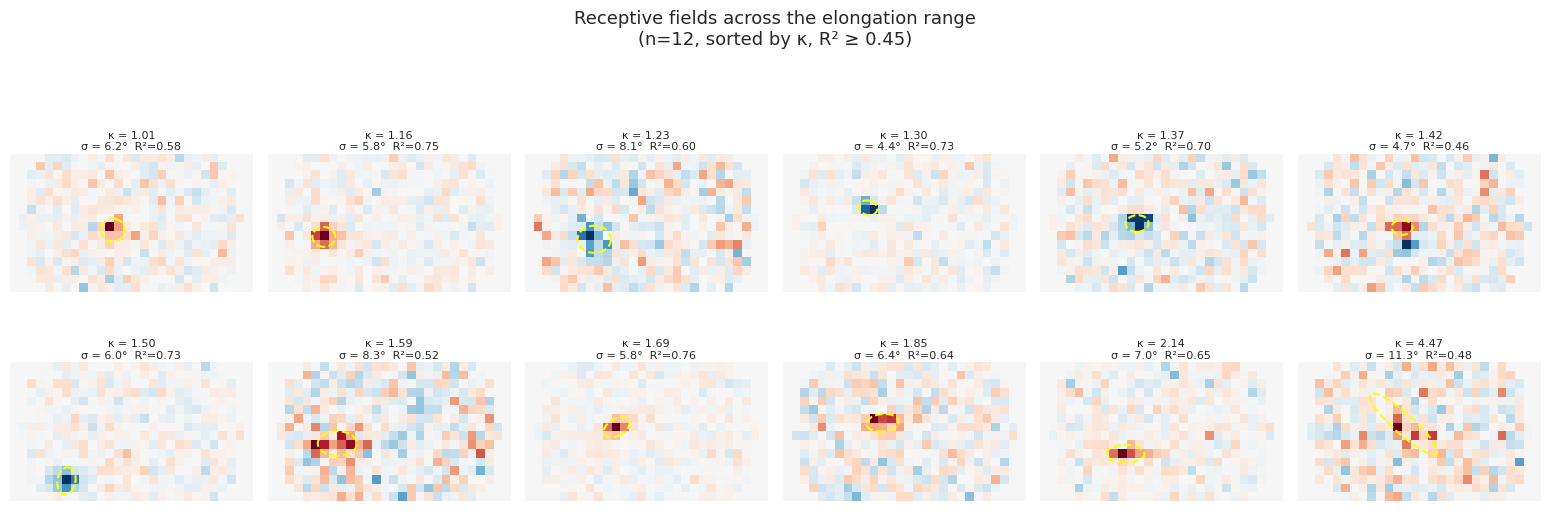

✓ Saved: fig_rf_gallery_kappa.png


In [9]:
# --- Config ---
N_COLS   = 6   # neurons per row
KAPPA_BINS = np.linspace(1.0, 2.8, N_COLS * 2 + 1)  # pick neurons spanning full κ range
QUALITY_THRESH = 0.45  # slightly stricter than extraction — only show clean RFs

# --- Select one representative neuron per κ bin ---
# Use the full combined dataframe (all_df) and re-load RFs on the fly
# Sort by κ, then pick evenly spaced examples
clean = all_df.dropna(subset=['sigma','kappa','theta','sigma_x','sigma_y',
                               'x0','y0','cell_id','exp_id']).copy()
clean = clean[clean['r_squared'] >= QUALITY_THRESH].reset_index(drop=True)
clean_sorted = clean.sort_values('kappa').reset_index(drop=True)

# Pick N_COLS*2 neurons spaced evenly across the κ distribution
indices = np.linspace(0, len(clean_sorted) - 1, N_COLS * 2).astype(int)
selected = clean_sorted.iloc[indices].reset_index(drop=True)

print(f"Selected {len(selected)} neurons spanning "
      f"κ = {selected['kappa'].min():.2f} – {selected['kappa'].max():.2f}")
print(selected[['container_id','cell_id','kappa','sigma','theta','r_squared']].to_string(index=False))

# --- Load RFs and plot ---
N_ROWS = 2
fig, axes = plt.subplots(N_ROWS, N_COLS,
                          figsize=(N_COLS * 2.6, N_ROWS * 2.8))
axes = axes.flatten()

for ax_i, (_, row) in enumerate(selected.iterrows()):
    ax = axes[ax_i]
    
    try:
        dataset  = boc.get_ophys_experiment_data(int(row['exp_id']))
        rf_on, rf_off, meta = reconstruct_rf(dataset, int(row['cell_id']))
        rf = rf_on - rf_off
        pix = meta['pixel_size_deg']
    except Exception as e:
        ax.text(0.5, 0.5, f"Load error\n{e}", ha='center', va='center',
                transform=ax.transAxes, fontsize=6)
        ax.axis('off')
        continue

    # Show RF
    vmax = np.abs(rf).max()
    ax.imshow(rf, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
              origin='upper', aspect='equal')

    # Overlay fitted ellipse (1σ contour)
    sx_px = row['sigma_x'] / pix
    sy_px = row['sigma_y'] / pix
    cx_px = row['x0']     / pix
    cy_px = row['y0']     / pix
    ell = Ellipse(xy=(cx_px, cy_px),
                  width=2 * sx_px, height=2 * sy_px,
                  angle=row['theta'],
                  edgecolor='yellow', facecolor='none',
                  linewidth=1.5, linestyle='--')
    ax.add_patch(ell)

    # Labels
    ax.set_title(f"κ = {row['kappa']:.2f}\nσ = {row['sigma']:.1f}°  R²={row['r_squared']:.2f}",
                 fontsize=8, pad=3)
    ax.axis('off')

fig.suptitle(
    f'Receptive fields across the elongation range\n'
    f'(n={len(selected)}, sorted by κ, R² ≥ {QUALITY_THRESH})',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(outputs_dir / 'fig_rf_gallery_kappa.png', dpi=180, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_rf_gallery_kappa.png')

Per-container σ CV (cascade smoothing hypothesis):
 container_id          cre_line  depth_um   n  sigma_mean  sigma_cv  cascade_ok  kappa_med
    511507650      Cux2-CreERT2       175  61    6.600378  0.236962        True   1.477855
    511509529      Cux2-CreERT2       175  58    7.500678  0.309970       False   1.657782
    511510650      Cux2-CreERT2       175  22    8.392685  0.307926       False   1.723587
    511510670      Cux2-CreERT2       175  57    8.149114  0.343541       False   1.529262
    511510718      Cux2-CreERT2       175  61    7.870869  0.272622        True   1.736450
    511510736      Cux2-CreERT2       175  33    6.697999  0.138293        True   1.488899
    511510855      Cux2-CreERT2       175  59    7.310691  0.346229       False   1.579242
    650389885 Slc17a7-IRES2-Cre       175  38    8.732935  0.358281       False   1.462832
    652842570 Slc17a7-IRES2-Cre       175  76    6.280116  0.487275       False   1.380542
    653125128 Slc17a7-IRES2-Cre       1

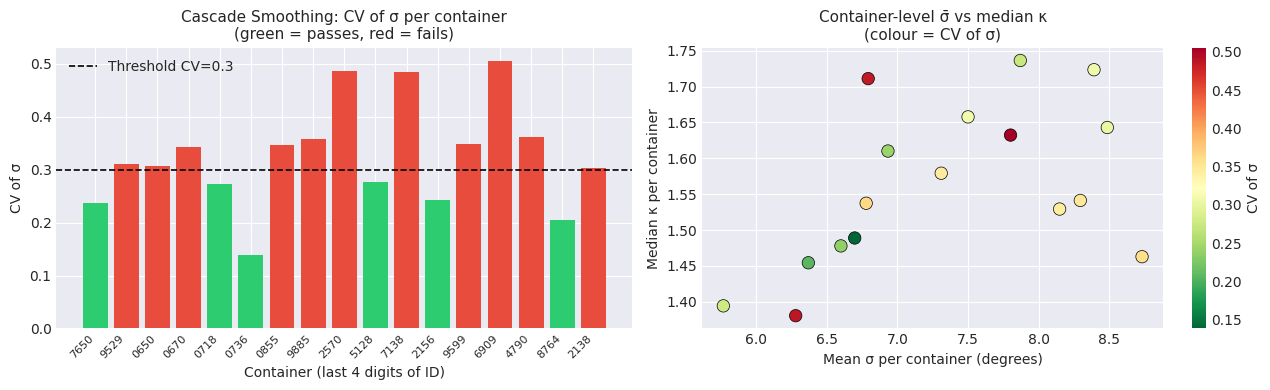

In [10]:
# Per-container CV of σ — tests whether cascade smoothing holds in each container
container_stats = all_df.groupby(['container_id', 'cre_line', 'depth_um']).agg(
    n          = ('sigma', 'count'),
    sigma_mean = ('sigma', 'mean'),
    sigma_std  = ('sigma', 'std'),
    kappa_med  = ('kappa', 'median'),
    kappa_std  = ('kappa', 'std'),
    r2_mean    = ('r_squared', 'mean'),
).reset_index()
container_stats['sigma_cv'] = container_stats['sigma_std'] / container_stats['sigma_mean']
container_stats['cascade_ok'] = container_stats['sigma_cv'] < 0.3

print('Per-container σ CV (cascade smoothing hypothesis):')
print(container_stats[['container_id','cre_line','depth_um','n',
                        'sigma_mean','sigma_cv','cascade_ok','kappa_med']].to_string(index=False))
print(f'\n→ {container_stats["cascade_ok"].sum()}/{len(container_stats)} containers '
      f'satisfy CV < 0.3 (cascade smoothing)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

colors = ['#2ecc71' if ok else '#e74c3c' for ok in container_stats['cascade_ok']]
ax1.bar(range(len(container_stats)), container_stats['sigma_cv'], color=colors, edgecolor='none')
ax1.axhline(0.3, color='black', linestyle='--', linewidth=1.2, label='Threshold CV=0.3')
ax1.set_xticks(range(len(container_stats)))
ax1.set_xticklabels([str(c)[-4:] for c in container_stats['container_id']], rotation=45, ha='right', fontsize=8)
ax1.set_xlabel('Container (last 4 digits of ID)')
ax1.set_ylabel('CV of σ')
ax1.set_title('Cascade Smoothing: CV of σ per container\n(green = passes, red = fails)', fontsize=11)
ax1.legend()

ax2.scatter(container_stats['sigma_mean'], container_stats['kappa_med'],
            c=container_stats['sigma_cv'], cmap='RdYlGn_r', s=80, edgecolors='k', linewidths=0.5)
ax2.set_xlabel('Mean σ per container (degrees)', fontsize=10)
ax2.set_ylabel('Median κ per container', fontsize=10)
ax2.set_title('Container-level σ̄ vs median κ\n(colour = CV of σ)', fontsize=11)
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r',
     norm=plt.Normalize(container_stats['sigma_cv'].min(), container_stats['sigma_cv'].max()))
plt.colorbar(sm, ax=ax2, label='CV of σ')

plt.tight_layout()
plt.savefig(outputs_dir / 'fig_cascade_smoothing.png', dpi=150, bbox_inches='tight')
plt.show()


---

## Part 3: Cortical Position Analysis

**Hypothesis (Lindeberg framework):**  
In primates/cats, κ varies with cortical position (pinwheel centre → low κ, periphery → high κ).  
In mice, prediction is **salt-and-pepper**: no systematic κ gradient.  
However, the σ-κ coupling found in Notebook 04 suggests an alternative organisation principle.

We test this per-container (within-imaging-plane, 400×400 μm) and then pool across containers.


In [11]:
# Per-container pairwise spatial autocorrelation
spat_results = []

for cid in sorted(all_df['container_id'].unique()):
    sub = all_df[all_df['container_id'] == cid].dropna(
        subset=['cortex_x_um', 'cortex_y_um', 'kappa', 'sigma']
    )
    if len(sub) < 10:
        print(f'  Container {cid}: skipping (n={len(sub)} < 10)')
        continue

    xy     = sub[['cortex_x_um', 'cortex_y_um']].values
    kappa  = sub['kappa'].values
    sigma  = sub['sigma'].values

    D   = squareform(pdist(xy))
    dK  = squareform(pdist(kappa[:, None]))
    dS  = squareform(pdist(sigma[:, None]))

    idx = np.triu_indices(len(sub), k=1)
    d, dk, ds = D[idx], dK[idx], dS[idx]

    r_dk, p_dk = pearsonr(d, dk)
    r_ds, p_ds = pearsonr(d, ds)
    r_sk, p_sk = pearsonr(sigma, kappa)
    r_xk, p_xk = pearsonr(sub['cortex_x_um'], kappa)
    r_yk, p_yk = pearsonr(sub['cortex_y_um'], kappa)

    row = sub.iloc[0]
    spat_results.append({
        'container_id': cid,
        'cre_line':     row['cre_line'],
        'depth_um':     row['depth_um'],
        'n':            len(sub),
        'r_dist_dk':    r_dk,  'p_dist_dk': p_dk,
        'r_dist_ds':    r_ds,  'p_dist_ds': p_ds,
        'r_sigma_kappa': r_sk, 'p_sigma_kappa': p_sk,
        'r_x_kappa':    r_xk,  'p_x_kappa': p_xk,
        'r_y_kappa':    r_yk,  'p_y_kappa': p_yk,
    })

spat_df = pd.DataFrame(spat_results)
print('Per-container cortical organisation results:')
print(spat_df[['container_id','n','r_dist_dk','r_sigma_kappa','r_x_kappa','r_y_kappa']]
      .to_string(index=False, float_format='{:.3f}'.format))

print(f'\nMedian r(dist, |Δκ|)  = {spat_df["r_dist_dk"].median():.3f}  '
      f'(IQR {spat_df["r_dist_dk"].quantile(0.25):.3f}–{spat_df["r_dist_dk"].quantile(0.75):.3f})')
print(f'Median r(σ, κ)        = {spat_df["r_sigma_kappa"].median():.3f}  '
      f'(IQR {spat_df["r_sigma_kappa"].quantile(0.25):.3f}–{spat_df["r_sigma_kappa"].quantile(0.75):.3f})')


Per-container cortical organisation results:
 container_id   n  r_dist_dk  r_sigma_kappa  r_x_kappa  r_y_kappa
    511507650  61      0.011          0.427     -0.042     -0.147
    511509529  58      0.079          0.317      0.250     -0.201
    511510650  22      0.002          0.427      0.332     -0.221
    511510670  57      0.042          0.647      0.325     -0.196
    511510718  61     -0.008          0.292      0.043      0.007
    511510736  33      0.039          0.374     -0.160      0.227
    511510855  59      0.035          0.367      0.078     -0.130
    650389885  38      0.006          0.184      0.101      0.188
    652842570  76     -0.097          0.507      0.045     -0.100
    653125128  77      0.012          0.565      0.039     -0.005
    661437138  61     -0.104          0.651     -0.045     -0.159
    661732156 130      0.011          0.439      0.042      0.244
    666589599  47     -0.136          0.498      0.085     -0.061
    680156909  40      0.141   

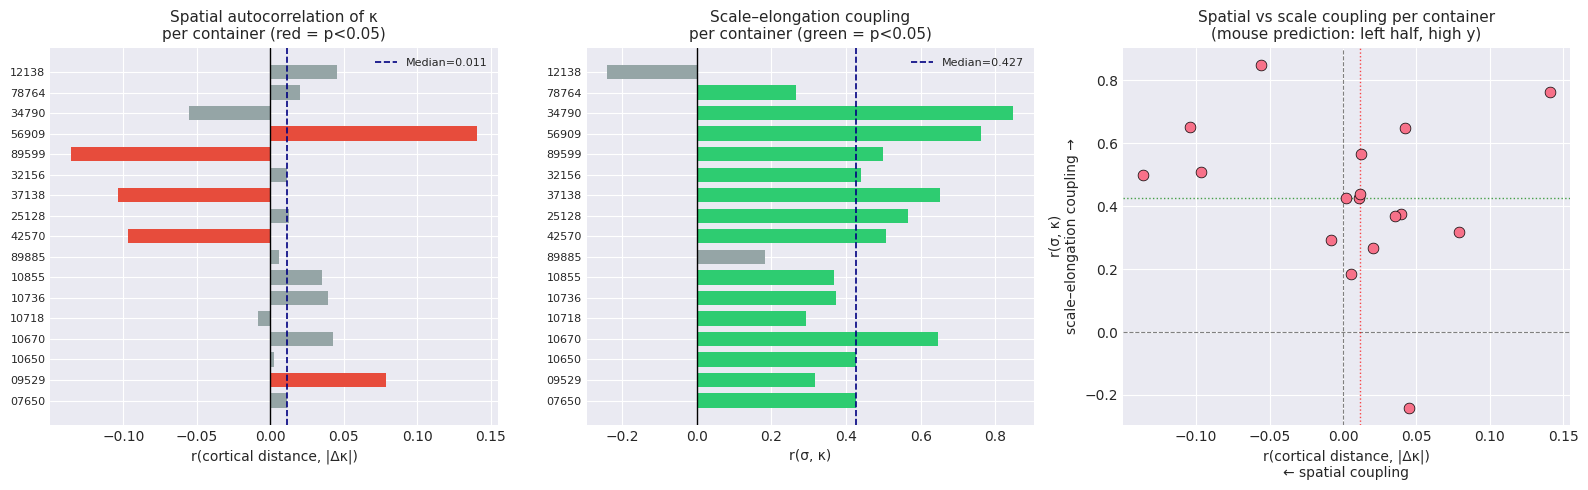

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Forest plot: r(dist, |Δκ|) per container ---
ax = axes[0]
y  = range(len(spat_df))
ax.barh(y, spat_df['r_dist_dk'], color=[
    '#e74c3c' if p < 0.05 else '#95a5a6' for p in spat_df['p_dist_dk']
], edgecolor='none', height=0.7)
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(list(y))
ax.set_yticklabels([str(c)[-5:] for c in spat_df['container_id']], fontsize=8)
ax.set_xlabel('r(cortical distance, |Δκ|)', fontsize=10)
ax.set_title('Spatial autocorrelation of κ\nper container (red = p<0.05)', fontsize=11)
ax.axvline(spat_df['r_dist_dk'].median(), color='navy', linestyle='--',
           linewidth=1.2, label=f'Median={spat_df["r_dist_dk"].median():.3f}')
ax.legend(fontsize=8)

# --- Forest plot: r(σ, κ) per container ---
ax = axes[1]
ax.barh(y, spat_df['r_sigma_kappa'], color=[
    '#2ecc71' if p < 0.05 else '#95a5a6' for p in spat_df['p_sigma_kappa']
], edgecolor='none', height=0.7)
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(list(y))
ax.set_yticklabels([str(c)[-5:] for c in spat_df['container_id']], fontsize=8)
ax.set_xlabel('r(σ, κ)', fontsize=10)
ax.set_title('Scale–elongation coupling\nper container (green = p<0.05)', fontsize=11)
ax.axvline(spat_df['r_sigma_kappa'].median(), color='navy', linestyle='--',
           linewidth=1.2, label=f'Median={spat_df["r_sigma_kappa"].median():.3f}')
ax.legend(fontsize=8)

# --- Compare the two coupling effects ---
ax = axes[2]
ax.scatter(spat_df['r_dist_dk'], spat_df['r_sigma_kappa'],
           s=60, edgecolors='k', linewidths=0.5, zorder=3)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axhline(spat_df['r_sigma_kappa'].median(), color='green', linewidth=1,
           linestyle=':', alpha=0.7)
ax.axvline(spat_df['r_dist_dk'].median(), color='red', linewidth=1,
           linestyle=':', alpha=0.7)
ax.set_xlabel('r(cortical distance, |Δκ|)\n← spatial coupling', fontsize=10)
ax.set_ylabel('r(σ, κ)\nscale–elongation coupling →', fontsize=10)
ax.set_title('Spatial vs scale coupling per container\n(mouse prediction: left half, high y)', fontsize=11)

plt.tight_layout()
plt.savefig(outputs_dir / 'fig_cortical_organisation.png', dpi=150, bbox_inches='tight')
plt.show()


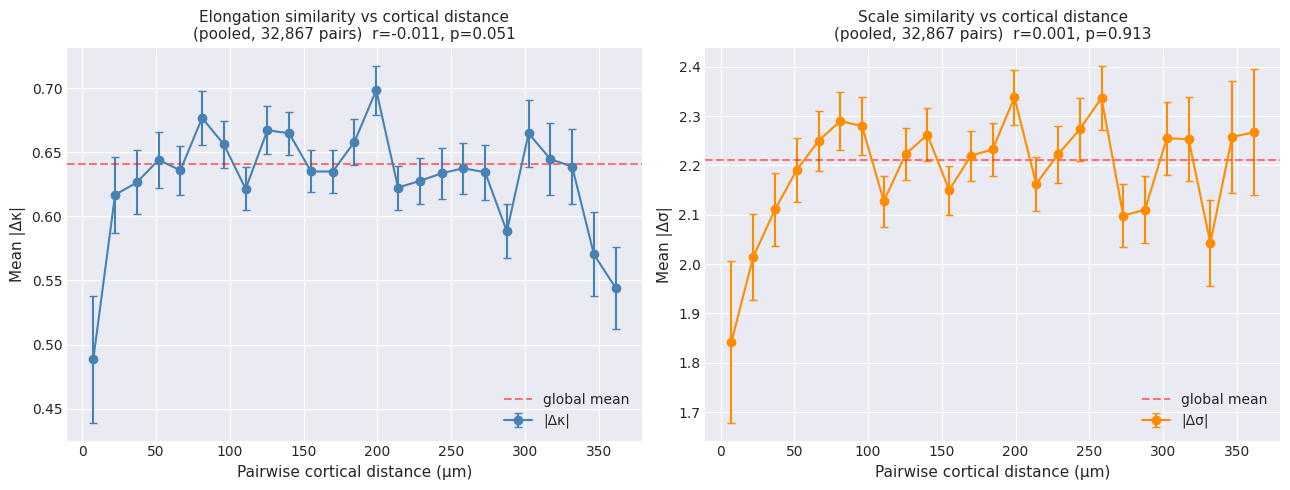

Pooled spatial autocorrelation (n=32,867 pairs):
  r(distance, |Δκ|) = -0.0108  (p=0.0508)
  r(distance, |Δσ|) = 0.0006  (p=0.9133)


In [13]:
# --- Pooled within-container pairwise autocorrelogram ---
# Pool pairs from all containers, normalised so each container contributes equally

all_dist, all_dk, all_ds = [], [], []

for cid in sorted(all_df['container_id'].unique()):
    sub = all_df[all_df['container_id'] == cid].dropna(
        subset=['cortex_x_um', 'cortex_y_um', 'kappa', 'sigma']
    )
    if len(sub) < 10:
        continue
    xy    = sub[['cortex_x_um', 'cortex_y_um']].values
    kappa = sub['kappa'].values
    sigma = sub['sigma'].values
    D     = squareform(pdist(xy))
    dK    = squareform(pdist(kappa[:, None]))
    dS    = squareform(pdist(sigma[:, None]))
    idx   = np.triu_indices(len(sub), k=1)
    all_dist.extend(D[idx])
    all_dk.extend(dK[idx])
    all_ds.extend(dS[idx])

all_dist = np.array(all_dist)
all_dk   = np.array(all_dk)
all_ds   = np.array(all_ds)

N_BINS = 25
dist_bins = np.linspace(0, np.percentile(all_dist, 98), N_BINS + 1)
bin_centers = 0.5 * (dist_bins[:-1] + dist_bins[1:])

mean_dk, sem_dk, mean_ds, sem_ds = [], [], [], []
for lo, hi in zip(dist_bins[:-1], dist_bins[1:]):
    mask = (all_dist >= lo) & (all_dist < hi)
    n    = mask.sum()
    if n > 5:
        mean_dk.append(all_dk[mask].mean())
        sem_dk.append(all_dk[mask].std() / np.sqrt(n))
        mean_ds.append(all_ds[mask].mean())
        sem_ds.append(all_ds[mask].std() / np.sqrt(n))
    else:
        mean_dk.append(np.nan); sem_dk.append(np.nan)
        mean_ds.append(np.nan); sem_ds.append(np.nan)

mean_dk, sem_dk = np.array(mean_dk), np.array(sem_dk)
mean_ds, sem_ds = np.array(mean_ds), np.array(sem_ds)

r_pool_dk, p_pool_dk = pearsonr(all_dist, all_dk)
r_pool_ds, p_pool_ds = pearsonr(all_dist, all_ds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.errorbar(bin_centers, mean_dk, yerr=sem_dk, fmt='o-', capsize=3,
            color='steelblue', linewidth=1.5, label='|Δκ|')
ax.axhline(all_dk.mean(), color='red', linestyle='--', alpha=0.5, label='global mean')
ax.set_xlabel('Pairwise cortical distance (μm)', fontsize=11)
ax.set_ylabel('Mean |Δκ|', fontsize=11)
ax.set_title(f'Elongation similarity vs cortical distance\n'
             f'(pooled, {len(all_dist):,} pairs)  r={r_pool_dk:.3f}, p={p_pool_dk:.3f}', fontsize=11)
ax.legend()

ax = axes[1]
ax.errorbar(bin_centers, mean_ds, yerr=sem_ds, fmt='o-', capsize=3,
            color='darkorange', linewidth=1.5, label='|Δσ|')
ax.axhline(all_ds.mean(), color='red', linestyle='--', alpha=0.5, label='global mean')
ax.set_xlabel('Pairwise cortical distance (μm)', fontsize=11)
ax.set_ylabel('Mean |Δσ|', fontsize=11)
ax.set_title(f'Scale similarity vs cortical distance\n'
             f'(pooled, {len(all_dist):,} pairs)  r={r_pool_ds:.3f}, p={p_pool_ds:.3f}', fontsize=11)
ax.legend()

plt.tight_layout()
plt.savefig(outputs_dir / 'fig_pooled_autocorrelogram.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pooled spatial autocorrelation (n={len(all_dist):,} pairs):')
print(f'  r(distance, |Δκ|) = {r_pool_dk:.4f}  (p={p_pool_dk:.4f})')
print(f'  r(distance, |Δσ|) = {r_pool_ds:.4f}  (p={p_pool_ds:.4f})')


In [14]:
r_sk_full, p_sk_full = pearsonr(
    all_df['sigma'].dropna(),
    all_df.loc[all_df['sigma'].notna(), 'kappa']
)

print('=' * 65)
print('CORTICAL ORGANISATION SUMMARY — FULL DATASET')
print('=' * 65)

print(f'\nNeurons: {len(all_df):,}  |  Containers: {all_df["container_id"].nunique()}')

print(f'\n--- Cascade Smoothing ---')
n_pass = container_stats['cascade_ok'].sum()
print(f'  {n_pass}/{len(container_stats)} containers satisfy σ CV < 0.3')
print(f'  Full-dataset σ CV = {sigma_cv:.3f}')

print(f'\n--- Elongation Variability (Lindeberg 2025c) ---')
print(f'  κ distribution: median={all_df["kappa"].median():.2f}, '
      f'SD={all_df["kappa"].std():.2f}')
print(f'  κ > 3 (highly elongated): {(all_df["kappa"]>3).mean()*100:.1f}%')

print(f'\n--- Cortical Position ---')
print(f'  Pooled r(dist, |Δκ|) = {r_pool_dk:.4f}  (p={p_pool_dk:.4f})')
print(f'  Median per-container  = {spat_df["r_dist_dk"].median():.3f}')
if abs(r_pool_dk) < 0.05 and p_pool_dk > 0.05:
    print('  → SALT-AND-PEPPER: κ not spatially organised ✓ (mouse prediction)')
elif r_pool_dk < -0.05:
    print('  → Weak clustering: nearby neurons share κ values')
else:
    print('  → Gradient structure detected')

print(f'\n--- Scale–Elongation Coupling ---')
print(f'  Full-dataset r(σ, κ)  = {r_sk_full:.3f}  (p={p_sk_full:.2e})')
print(f'  Median per-container  = {spat_df["r_sigma_kappa"].median():.3f}')

print(f'\n--- Interpretation for Lindeberg (2025c) ---')
print(f'  κ is VARIABLE across neurons (not fixed at 1) → supports elongation variability hypothesis')
print(f'  κ is NOT spatially structured → no pinwheel-like gradients in mice')
print(f'  κ co-varies with σ (r={r_sk_full:.3f}) → scale-coupled, not position-coupled organisation')
print(f'  This is a distinct organisational principle from primate V1.')


CORTICAL ORGANISATION SUMMARY — FULL DATASET

Neurons: 974  |  Containers: 17

--- Cascade Smoothing ---
  6/17 containers satisfy σ CV < 0.3
  Full-dataset σ CV = 0.353

--- Elongation Variability (Lindeberg 2025c) ---
  κ distribution: median=1.54, SD=0.72
  κ > 3 (highly elongated): 5.5%

--- Cortical Position ---
  Pooled r(dist, |Δκ|) = -0.0108  (p=0.0508)
  Median per-container  = 0.011
  → SALT-AND-PEPPER: κ not spatially organised ✓ (mouse prediction)

--- Scale–Elongation Coupling ---
  Full-dataset r(σ, κ)  = 0.448  (p=3.49e-49)
  Median per-container  = 0.427

--- Interpretation for Lindeberg (2025c) ---
  κ is VARIABLE across neurons (not fixed at 1) → supports elongation variability hypothesis
  κ is NOT spatially structured → no pinwheel-like gradients in mice
  κ co-varies with σ (r=0.448) → scale-coupled, not position-coupled organisation
  This is a distinct organisational principle from primate V1.


In [15]:
# Save full combined dataset
out_combined = outputs_dir / 'rf_params_all_containers.csv'
all_df.to_csv(out_combined, index=False)
print(f'✓ Combined dataset saved: {out_combined}')
print(f'  Shape: {all_df.shape}')

out_spat = outputs_dir / 'spatial_organisation_per_container.csv'
spat_df.to_csv(out_spat, index=False)
print(f'✓ Spatial stats saved:    {out_spat}')

out_stats = outputs_dir / 'container_stats.csv'
container_stats.to_csv(out_stats, index=False)
print(f'✓ Container stats saved:  {out_stats}')


✓ Combined dataset saved: /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/rf_params_all_containers.csv
  Shape: (974, 28)
✓ Spatial stats saved:    /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/spatial_organisation_per_container.csv
✓ Container stats saved:  /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/container_stats.csv


---

## Part 4: Visual Field Position — Monocular vs Binocular Zone

In mouse V1, the **binocular zone** corresponds to RFs centred within ~40° of the vertical meridian
(x₀ < 40°). The **monocular (temporal) crescent** extends from ~40–80°.

**Questions:**
- Do σ (RF size) and κ (elongation) differ between zones?
- Does RF size increase with eccentricity (as in primates)?

Dataset: ridge-regression fits (878 neurons, all 17 containers).


Ridge dataset: 878 neurons across 17 containers
  Binocular (x₀ < 40°) : 349 (39.7%)
  Monocular (x₀ ≥ 40°) : 529 (60.3%)

x₀ range : 13.1° – 77.6°
y₀ range : 14.9° – 71.7°


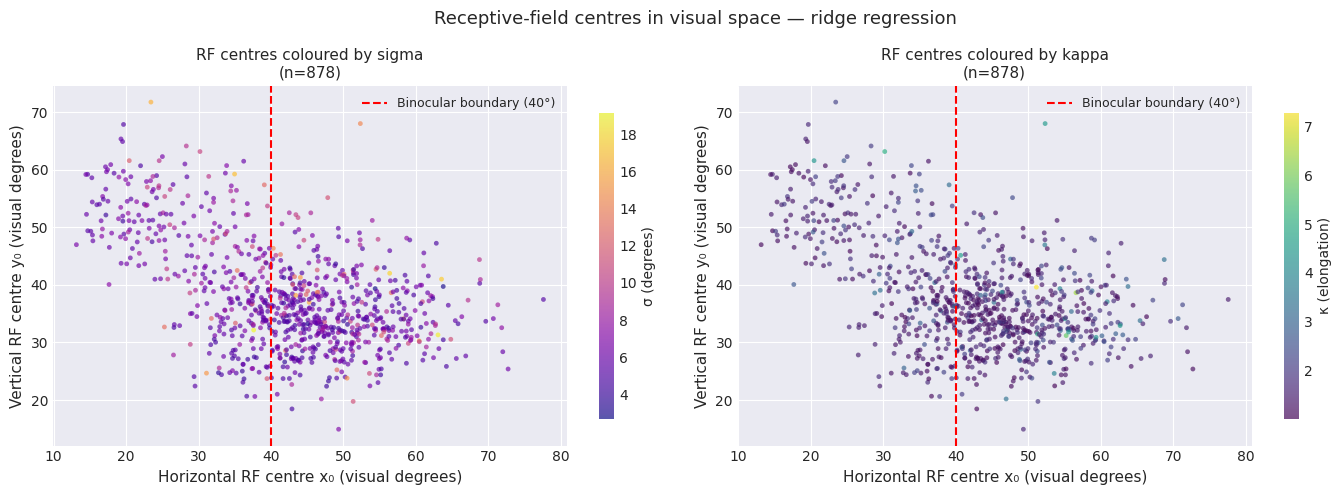

✓ Saved: fig_rf_center_map.png


In [16]:
# ── Load ridge results (has sigma_x, sigma_y, x0, y0) ─────────────────────────
ridge_path = base_dir / 'outputs' / 'rf_params' / 'ridge' / 'rf_params_ridge_all_containers.csv'
rdf = pd.read_csv(ridge_path)
for col in ['sigma', 'sigma_x', 'sigma_y', 'kappa', 'theta', 'x0', 'y0', 'r_squared']:
    rdf[col] = pd.to_numeric(rdf[col], errors='coerce')

BIN_DEG = 40.0   # binocular / monocular boundary (azimuth, degrees)
rdf['zone'] = np.where(rdf['x0'] < BIN_DEG, 'binocular', 'monocular')
n_bino = (rdf['zone'] == 'binocular').sum()
n_mono = (rdf['zone'] == 'monocular').sum()

print(f'Ridge dataset: {len(rdf):,} neurons across {rdf["container_id"].nunique()} containers')
print(f'  Binocular (x₀ < {int(BIN_DEG)}°) : {n_bino} ({100*n_bino/len(rdf):.1f}%)')
print(f'  Monocular (x₀ ≥ {int(BIN_DEG)}°) : {n_mono} ({100*n_mono/len(rdf):.1f}%)')
print(f'\nx₀ range : {rdf["x0"].min():.1f}° – {rdf["x0"].max():.1f}°')
print(f'y₀ range : {rdf["y0"].min():.1f}° – {rdf["y0"].max():.1f}°')

# ── RF centre scatter coloured by σ and κ ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, cmap, label in [
    (axes[0], 'sigma', 'plasma',  'σ (degrees)'),
    (axes[1], 'kappa', 'viridis', 'κ (elongation)'),
]:
    sc = ax.scatter(rdf['x0'], rdf['y0'],
                    c=rdf[col], cmap=cmap, s=12, alpha=0.65, linewidths=0)
    plt.colorbar(sc, ax=ax, label=label, shrink=0.85)
    ax.axvline(BIN_DEG, color='red', linestyle='--', linewidth=1.5,
               label=f'Binocular boundary ({int(BIN_DEG)}°)')
    ax.set_xlabel('Horizontal RF centre x₀ (visual degrees)', fontsize=11)
    ax.set_ylabel('Vertical RF centre y₀ (visual degrees)', fontsize=11)
    ax.set_title(f'RF centres coloured by {col}\n(n={len(rdf):,})', fontsize=11)
    ax.legend(fontsize=9)

fig.suptitle('Receptive-field centres in visual space — ridge regression', fontsize=13)
plt.tight_layout()
plt.savefig(ridge_path.parent / 'fig_rf_center_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_rf_center_map.png')


MONOCULAR vs BINOCULAR — STATISTICAL COMPARISON

σ (scale, °):
  Binocular  mean ± SD = 6.762 ± 2.090  (n=349)
  Monocular  mean ± SD = 6.510 ± 2.340  (n=529)
  Mann-Whitney U = 105509,  p = 0.0003
  Cohen's d = 0.112  (|d|<0.2 negligible, 0.2–0.5 small, >0.5 medium)

κ (elongation):
  Binocular  mean ± SD = 1.641 ± 0.519  (n=349)
  Monocular  mean ± SD = 1.693 ± 0.709  (n=529)
  Mann-Whitney U = 92588,  p = 0.9400
  Cohen's d = -0.081  (|d|<0.2 negligible, 0.2–0.5 small, >0.5 medium)

--- Linear regression vs visual eccentricity (x₀) ---
  σ ~ x₀:  slope=-0.0003/°,  r=-0.002,  p=0.9595
  κ ~ x₀:  slope=0.0063/°,  r=0.118,  p=0.0005


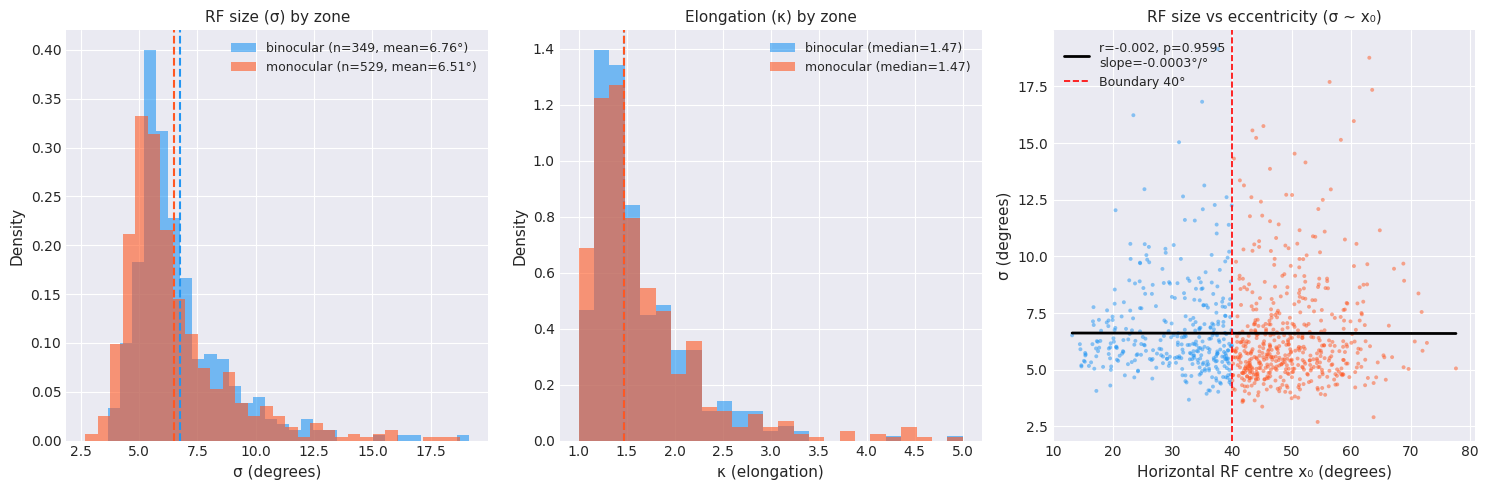

✓ Saved: fig_rf_zone_comparison.png


In [17]:
from scipy.stats import mannwhitneyu, linregress

# ── Statistical comparison: monocular vs binocular ───────────────────────────
bino = rdf[rdf['zone'] == 'binocular']
mono = rdf[rdf['zone'] == 'monocular']

def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_sd = np.sqrt(((na-1)*a.std()**2 + (nb-1)*b.std()**2) / (na+nb-2))
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else 0.0

print('=' * 65)
print('MONOCULAR vs BINOCULAR — STATISTICAL COMPARISON')
print('=' * 65)
for param, label in [('sigma', 'σ (scale, °)'), ('kappa', 'κ (elongation)')]:
    a = bino[param].dropna()
    b = mono[param].dropna()
    u, p = mannwhitneyu(a, b, alternative='two-sided')
    d    = cohens_d(a, b)
    print(f'\n{label}:')
    print(f'  Binocular  mean ± SD = {a.mean():.3f} ± {a.std():.3f}  (n={len(a)})')
    print(f'  Monocular  mean ± SD = {b.mean():.3f} ± {b.std():.3f}  (n={len(b)})')
    print(f'  Mann-Whitney U = {u:.0f},  p = {p:.4f}')
    print(f'  Cohen\'s d = {d:.3f}  (|d|<0.2 negligible, 0.2–0.5 small, >0.5 medium)')

print(f'\n--- Linear regression vs visual eccentricity (x₀) ---')
for param, label in [('sigma', 'σ'), ('kappa', 'κ')]:
    valid = rdf[['x0', param]].dropna()
    slope, intercept, r, p, _ = linregress(valid['x0'], valid[param])
    print(f'  {label} ~ x₀:  slope={slope:.4f}/°,  r={r:.3f},  p={p:.4f}')

# ── Figure: zone comparisons ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# σ by zone
ax = axes[0]
for zone, color in [('binocular', '#2196F3'), ('monocular', '#FF5722')]:
    vals = rdf[rdf['zone'] == zone]['sigma'].dropna()
    n    = len(vals)
    ax.hist(vals, bins=30, alpha=0.6, color=color, density=True, edgecolor='none',
            label=f'{zone} (n={n}, mean={vals.mean():.2f}°)')
    ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=1.5)
ax.set_xlabel('σ (degrees)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('RF size (σ) by zone', fontsize=11)
ax.legend(fontsize=9)

# κ by zone
ax = axes[1]
for zone, color in [('binocular', '#2196F3'), ('monocular', '#FF5722')]:
    vals = rdf[rdf['zone'] == zone]['kappa'].dropna()
    ax.hist(vals, bins=25, range=(1, 5), alpha=0.6, color=color, density=True, edgecolor='none',
            label=f'{zone} (median={vals.median():.2f})')
    ax.axvline(vals.median(), color=color, linestyle='--', linewidth=1.5)
ax.set_xlabel('κ (elongation)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Elongation (κ) by zone', fontsize=11)
ax.legend(fontsize=9)

# σ vs x0 scatter + regression line
ax = axes[2]
zone_colors = rdf['zone'].map({'binocular': '#2196F3', 'monocular': '#FF5722'})
ax.scatter(rdf['x0'], rdf['sigma'], c=zone_colors, s=8, alpha=0.5, linewidths=0)
valid = rdf[['x0', 'sigma']].dropna()
slope, intercept, r, p, _ = linregress(valid['x0'], valid['sigma'])
x_fit = np.array([valid['x0'].min(), valid['x0'].max()])
ax.plot(x_fit, slope * x_fit + intercept, 'k-', linewidth=2,
        label=f'r={r:.3f}, p={p:.4f}\nslope={slope:.4f}°/°')
ax.axvline(BIN_DEG, color='red', linestyle='--', linewidth=1.2, label=f'Boundary {int(BIN_DEG)}°')
ax.set_xlabel('Horizontal RF centre x₀ (degrees)', fontsize=11)
ax.set_ylabel('σ (degrees)', fontsize=11)
ax.set_title('RF size vs eccentricity (σ ~ x₀)', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(ridge_path.parent / 'fig_rf_zone_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_rf_zone_comparison.png')


---

## Part 5: Spatial Scale Decomposition — log(σ), σ_x, σ_y

The Lindeberg convention uses the geometric mean σ = √(σ_x · σ_y). But the two axes may have distinct
biological meanings:

- **σ_major = max(σ_x, σ_y)**: extent along preferred orientation
- **σ_minor = min(σ_x, σ_y)**: extent perpendicular to orientation

**Questions:**
- Is σ log-normally distributed (as expected for a scale-invariant parameter)?
- Does κ > 1 arise mainly from major-axis *expansion* or minor-axis *compression*?
- Do the two axes scale together, or do they decouple?

Dataset: ridge-regression fits (878 neurons).


Geometric mean check:  median |rel error| = 0.0000  (max = 0.0000)

Axis summary (degrees):
  σ_major  mean=8.65°  median=7.29°
  σ_minor  mean=5.18°  median=4.83°
  σ (geo)  mean=6.61°       median=5.95°


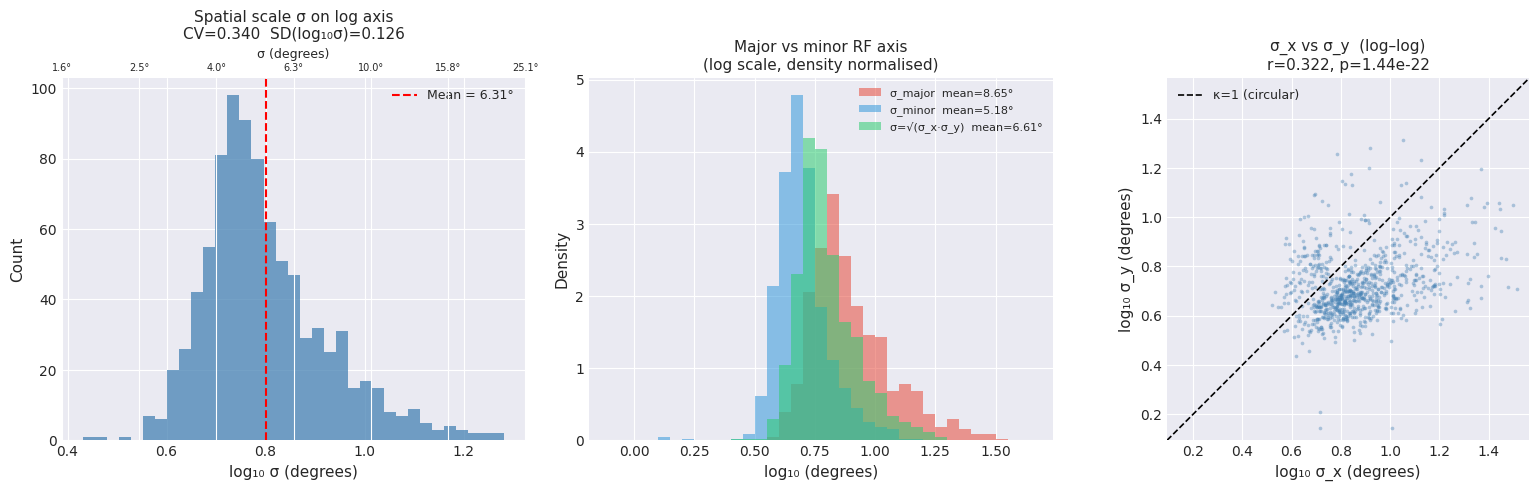

✓ Saved: fig_log_sigma_distributions.png


In [18]:
# ── Geometric mean verification + log-scale distributions ────────────────────
rdf['sigma_geomean'] = np.sqrt(rdf['sigma_x'] * rdf['sigma_y'])
rel_err = ((rdf['sigma'] - rdf['sigma_geomean']) / rdf['sigma']).abs()
print(f'Geometric mean check:  median |rel error| = {rel_err.median():.4f}  '
      f'(max = {rel_err.max():.4f})')

rdf['sigma_major'] = rdf[['sigma_x', 'sigma_y']].max(axis=1)
rdf['sigma_minor'] = rdf[['sigma_x', 'sigma_y']].min(axis=1)
rdf['log_sigma']   = np.log10(rdf['sigma'])
rdf['log_sx']      = np.log10(rdf['sigma_x'])
rdf['log_sy']      = np.log10(rdf['sigma_y'])
rdf['log_smaj']    = np.log10(rdf['sigma_major'])
rdf['log_smin']    = np.log10(rdf['sigma_minor'])
rdf['log_kappa']   = np.log(rdf['kappa'])   # natural log

print(f'\nAxis summary (degrees):')
print(f'  σ_major  mean={rdf["sigma_major"].mean():.2f}°  median={rdf["sigma_major"].median():.2f}°')
print(f'  σ_minor  mean={rdf["sigma_minor"].mean():.2f}°  median={rdf["sigma_minor"].median():.2f}°')
print(f'  σ (geo)  mean={rdf["sigma"].mean():.2f}°       median={rdf["sigma"].median():.2f}°')

# ── Figure: log-scale distributions ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: log10(sigma) histogram with secondary degree axis
ax = axes[0]
ax.hist(rdf['log_sigma'].dropna(), bins=35, edgecolor='none', alpha=0.75, color='steelblue')
ax.axvline(rdf['log_sigma'].mean(), color='red', linestyle='--',
           label=f"Mean = {10**rdf['log_sigma'].mean():.2f}°")
sigma_cv = rdf['sigma'].std() / rdf['sigma'].mean()
log_cv   = rdf['log_sigma'].std()
ax.set_xlabel('log₁₀ σ (degrees)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title(f'Spatial scale σ on log axis\nCV={sigma_cv:.3f}  SD(log₁₀σ)={log_cv:.3f}', fontsize=11)
ax.legend(fontsize=9)
# Add degree tick labels on top
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ticks = ax.get_xticks()
ax2.set_xticks(ticks)
ax2.set_xticklabels([f'{10**t:.1f}°' for t in ticks], fontsize=7)
ax2.set_xlabel('σ (degrees)', fontsize=9)

# Panel B: overlaid major / minor / geomean distributions
ax = axes[1]
bins = np.linspace(-0.1, 1.65, 36)
for col, color, label in [
    ('log_smaj', '#e74c3c', f'σ_major  mean={rdf["sigma_major"].mean():.2f}°'),
    ('log_smin', '#3498db', f'σ_minor  mean={rdf["sigma_minor"].mean():.2f}°'),
    ('log_sigma','#2ecc71', f'σ=√(σ_x·σ_y)  mean={rdf["sigma"].mean():.2f}°'),
]:
    ax.hist(rdf[col].dropna(), bins=bins, alpha=0.55, color=color,
            label=label, density=True, edgecolor='none')
ax.set_xlabel('log₁₀ (degrees)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Major vs minor RF axis\n(log scale, density normalised)', fontsize=11)
ax.legend(fontsize=8)

# Panel C: sigma_x vs sigma_y scatter (log–log) with identity line
ax = axes[2]
r_xy, p_xy = pearsonr(rdf['log_sx'].dropna(),
                       rdf.loc[rdf['log_sx'].notna(), 'log_sy'])
ax.scatter(rdf['log_sx'], rdf['log_sy'], s=7, alpha=0.4,
           linewidths=0, color='steelblue')
lo = min(rdf['log_sx'].min(), rdf['log_sy'].min()) - 0.05
hi = max(rdf['log_sx'].max(), rdf['log_sy'].max()) + 0.05
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.2, label='κ=1 (circular)')
ax.set_xlabel('log₁₀ σ_x (degrees)', fontsize=11)
ax.set_ylabel('log₁₀ σ_y (degrees)', fontsize=11)
ax.set_title(f'σ_x vs σ_y  (log–log)\nr={r_xy:.3f}, p={p_xy:.2e}', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(ridge_path.parent / 'fig_log_sigma_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_log_sigma_distributions.png')


AXIS-SPECIFIC ELONGATION DECOMPOSITION

σ axis statistics (degrees):
  σ_major     mean=8.653°  median=7.285°  CV=0.481
  σ_minor     mean=5.185°  median=4.833°  CV=0.291
  σ (geo)     mean=6.610°  median=5.955°  CV=0.340

Correlation with σ (geometric mean):
  r(σ, σ_major) = 0.924  (p=0.00e+00)
  r(σ, σ_minor) = 0.867  (p=7.02e-268)
  → Larger RFs have disproportionately larger major axis

Correlation with log κ:
  r(log σ_major, log κ) = 0.749  (p=1.45e-158)
  r(log σ_minor, log κ) = -0.042  (p=2.18e-01)
  → κ variation mostly driven by major axis expansion


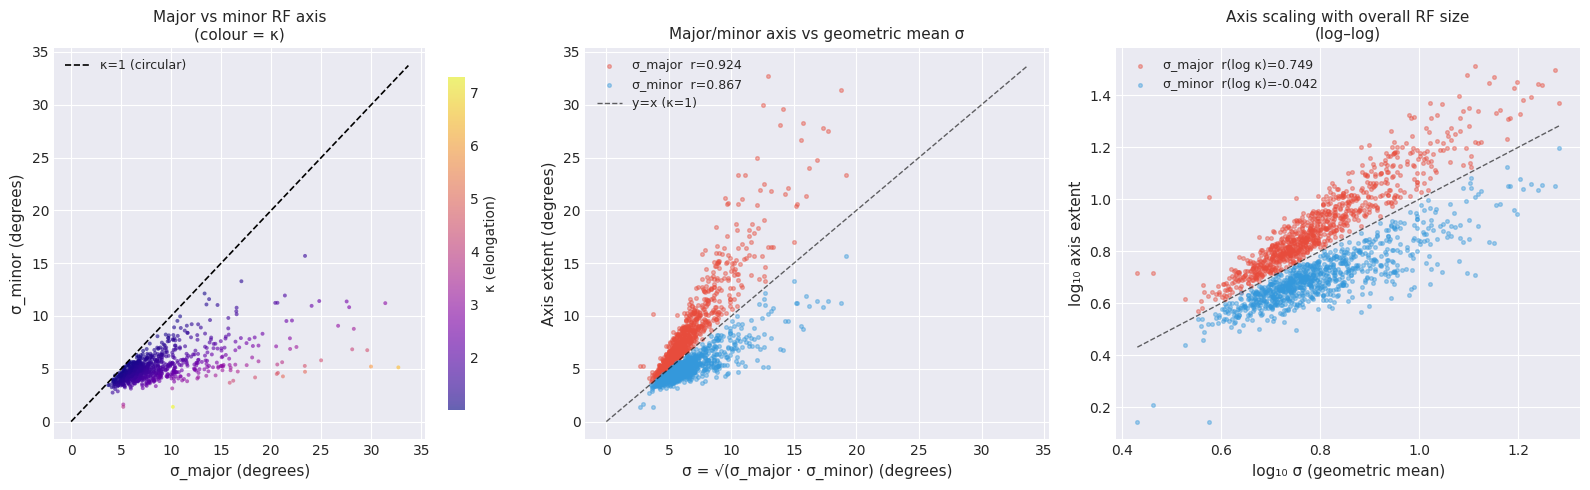

✓ Saved: fig_elongation_decomposition.png

SUMMARY
  σ_major mean = 8.65°  (30.9% above geometric mean σ)
  σ_minor mean = 5.18°  (21.6% below geometric mean σ)
  Median κ = 1.47  →  σ_major/σ_minor ratio = 1.47


In [19]:
# ── Elongation decomposition ─────────────────────────────────────────────────
# sigma_major / sigma_minor relative to geometric mean sigma
# sigma_major = sigma * sqrt(kappa)  -->  log(sigma_major) = log(sigma) + 0.5*log(kappa)
# sigma_minor = sigma / sqrt(kappa)  -->  log(sigma_minor) = log(sigma) - 0.5*log(kappa)
#
# The interesting question: as sigma increases, does sigma_major grow faster than sigma_minor?
# And is kappa driven primarily by major-axis expansion or minor-axis compression?

r_maj, p_maj = pearsonr(rdf['sigma'].dropna(), rdf.loc[rdf['sigma'].notna(), 'sigma_major'])
r_min, p_min = pearsonr(rdf['sigma'].dropna(), rdf.loc[rdf['sigma'].notna(), 'sigma_minor'])

r_kappa_major = pearsonr(rdf['log_smaj'].dropna(), rdf.loc[rdf['log_smaj'].notna(), 'log_kappa'])
r_kappa_minor = pearsonr(rdf['log_smin'].dropna(), rdf.loc[rdf['log_smin'].notna(), 'log_kappa'])

print('=' * 65)
print('AXIS-SPECIFIC ELONGATION DECOMPOSITION')
print('=' * 65)
print(f'\nσ axis statistics (degrees):')
for col, label in [('sigma_major', 'σ_major'), ('sigma_minor', 'σ_minor'), ('sigma', 'σ (geo)')]:
    print(f'  {label:10s}  mean={rdf[col].mean():.3f}°  median={rdf[col].median():.3f}°  '
          f'CV={rdf[col].std()/rdf[col].mean():.3f}')

print(f'\nCorrelation with σ (geometric mean):')
print(f'  r(σ, σ_major) = {r_maj:.3f}  (p={p_maj:.2e})')
print(f'  r(σ, σ_minor) = {r_min:.3f}  (p={p_min:.2e})')
print(f'  → Larger RFs have disproportionately larger {"major" if r_maj > r_min else "minor"} axis')

print(f'\nCorrelation with log κ:')
print(f'  r(log σ_major, log κ) = {r_kappa_major[0]:.3f}  (p={r_kappa_major[1]:.2e})')
print(f'  r(log σ_minor, log κ) = {r_kappa_minor[0]:.3f}  (p={r_kappa_minor[1]:.2e})')
if abs(r_kappa_major[0]) > abs(r_kappa_minor[0]):
    print('  → κ variation mostly driven by major axis expansion')
else:
    print('  → κ variation mostly driven by minor axis compression')

# ── Figure: elongation decomposition ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: sigma_major vs sigma_minor, coloured by kappa
ax = axes[0]
sc = ax.scatter(rdf['sigma_major'], rdf['sigma_minor'],
                c=rdf['kappa'], cmap='plasma', s=8, alpha=0.6, linewidths=0)
plt.colorbar(sc, ax=ax, label='κ (elongation)', shrink=0.85)
lim = rdf['sigma_major'].max() + 1
ax.plot([0, lim], [0, lim], 'k--', linewidth=1.2, label='κ=1 (circular)')
ax.set_xlabel('σ_major (degrees)', fontsize=11)
ax.set_ylabel('σ_minor (degrees)', fontsize=11)
ax.set_title('Major vs minor RF axis\n(colour = κ)', fontsize=11)
ax.legend(fontsize=9)

# Panel B: sigma_major and sigma_minor vs geometric mean sigma
ax = axes[1]
ax.scatter(rdf['sigma'], rdf['sigma_major'],
           s=7, alpha=0.4, color='#e74c3c', label=f'σ_major  r={r_maj:.3f}')
ax.scatter(rdf['sigma'], rdf['sigma_minor'],
           s=7, alpha=0.4, color='#3498db', label=f'σ_minor  r={r_min:.3f}')
lim = rdf[['sigma', 'sigma_major']].max().max() + 1
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.6, label='y=x (κ=1)')
ax.set_xlabel('σ = √(σ_major · σ_minor) (degrees)', fontsize=11)
ax.set_ylabel('Axis extent (degrees)', fontsize=11)
ax.set_title('Major/minor axis vs geometric mean σ', fontsize=11)
ax.legend(fontsize=9)

# Panel C: log sigma_major and sigma_minor vs log sigma
ax = axes[2]
ax.scatter(rdf['log_sigma'], rdf['log_smaj'],
           s=7, alpha=0.4, color='#e74c3c',
           label=f'σ_major  r(log κ)={r_kappa_major[0]:.3f}')
ax.scatter(rdf['log_sigma'], rdf['log_smin'],
           s=7, alpha=0.4, color='#3498db',
           label=f'σ_minor  r(log κ)={r_kappa_minor[0]:.3f}')
ls = np.linspace(rdf['log_sigma'].min(), rdf['log_sigma'].max(), 100)
ax.plot(ls, ls, 'k--', linewidth=1, alpha=0.6)
ax.set_xlabel('log₁₀ σ (geometric mean)', fontsize=11)
ax.set_ylabel('log₁₀ axis extent', fontsize=11)
ax.set_title('Axis scaling with overall RF size\n(log–log)', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(ridge_path.parent / 'fig_elongation_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_elongation_decomposition.png')

print('\n' + '=' * 65)
print('SUMMARY')
print('=' * 65)
pct_above = 100 * (rdf['sigma_major'].mean() / rdf['sigma'].mean() - 1)
pct_below = 100 * (1 - rdf['sigma_minor'].mean() / rdf['sigma'].mean())
print(f'  σ_major mean = {rdf["sigma_major"].mean():.2f}°  ({pct_above:.1f}% above geometric mean σ)')
print(f'  σ_minor mean = {rdf["sigma_minor"].mean():.2f}°  ({pct_below:.1f}% below geometric mean σ)')
print(f'  Median κ = {rdf["kappa"].median():.2f}  →  σ_major/σ_minor ratio = {rdf["kappa"].median():.2f}')
